In [1]:
import os
from google.colab import drive

# Google Drive'a bağlanın
drive.mount('/content/drive')

Mounted at /content/drive


Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
Model: NASNetMobile, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.001, Validation Accuracy: 0.625
Model: NASNetMobile, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.01, Validation Accuracy: 0.375
Model: NASNetMobile, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.1, Validation Accuracy: 0.375
Model: NASNetMobile, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.001, Validation Accuracy: 0.4375
Model: NASNetMobile, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.01, Validation Accuracy: 0.5625
Model: NASNetMobile, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.1, Validation Accuracy: 0.4375
Model: NASNetMobile, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.001, Validation Accuracy: 0.5625
Model: NASNetMobile, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.01, Validation Accuracy: 0.5625
Model: NASNetMobile, Activation: relu, Dropout Rate: 0.2, Learning

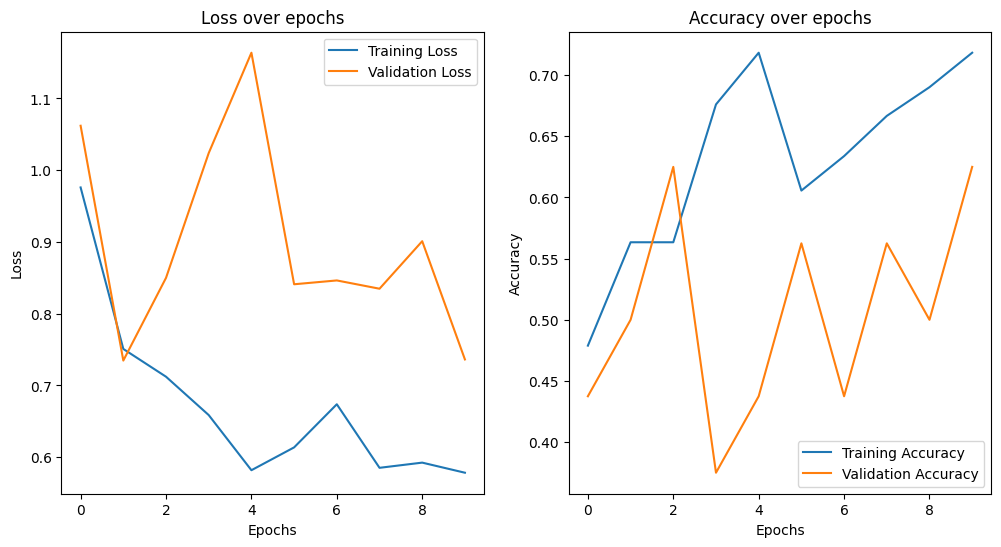

5/5 [==============================] - 5s 355ms/step
Weighted Precision: 0.5529411764705882
Weighted Recall: 0.5294117647058824
Weighted F1 Score: 0.5092436974789916
Micro Precision: 0.5294117647058824
Micro Recall: 0.5294117647058824
Micro F1 Score: 0.5294117647058824
Macro Precision: 0.55
Macro Recall: 0.5416666666666666
Macro F1 Score: 0.5142857142857142
Precision (None): [0.5 0.6]
Recall (None): [0.75       0.33333333]
F1 Score (None): [0.6        0.42857143]


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [0.001, 0.01, 0.1]
epochs = 10  # Start with fewer epochs for testing

best_accuracy = 0
best_params = {}
all_results = []

base_models = {
    'NASNetMobile': NASNetMobile
}

results_file = 'training_resultsNASNetMobile.json'
if os.path.exists(results_file):
    with open(results_file, 'r') as file:
        all_results = json.load(file)
else:
    all_results = []

for model_name, base_model_fn in base_models.items():
    for activation in activations:
        for dropout_rate in dropout_rates:
            for learning_rate in learning_rates:
                try:
                    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
                    for layer in base_model.layers:
                        layer.trainable = False

                    x = GlobalAveragePooling2D()(base_model.output)
                    x = Dense(512, activation=activation)(x)
                    x = Dropout(dropout_rate)(x)
                    output = Dense(1, activation='sigmoid')(x)

                    model = Model(inputs=base_model.input, outputs=output)
                    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                                  loss='binary_crossentropy',
                                  metrics=['accuracy'])

                    history = model.fit(
                        train_generator,
                        steps_per_epoch=train_generator.samples // train_generator.batch_size,
                        epochs=epochs,
                        validation_data=val_generator,
                        validation_steps=val_generator.samples // val_generator.batch_size,
                        verbose=0
                    )

                    val_accuracy = history.history['val_accuracy'][-1]
                    result = {
                        'model': model_name,
                        'activation': activation,
                        'dropout_rate': dropout_rate,
                        'learning_rate': learning_rate,
                        'val_accuracy': val_accuracy,
                        'history': history.history
                    }
                    all_results.append(result)

                    if val_accuracy > best_accuracy:
                        best_accuracy = val_accuracy
                        best_params = result
                        best_output = output  # Kaydedilen çıktı tensoru

                    with open(results_file, 'w') as file:
                        json.dump(all_results, file)

                    print(f"Model: {model_name}, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}")

                except Exception as e:
                    print(f"Error with model {model_name}, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# En iyi modelin giriş ve çıkış tensorlarını kullanarak yeniden oluşturulması
base_model = NASNetMobile(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=best_params['activation'])(x)
x = Dropout(best_params['dropout_rate'])(x)
best_output = Dense(1, activation='sigmoid')(x)  # Kaydedilen çıktı tensoru kullanılmalı

best_model = Model(inputs=base_model.input, outputs=best_output)
best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
9406464/9406464 [==============================] - 1s 0us/step
Model: MobileNetV2, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.001, Validation Accuracy: 0.375
Model: MobileNetV2, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.01, Validation Accuracy: 0.375
Model: MobileNetV2, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.1, Validation Accuracy: 0.625
Model: MobileNetV2, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.001, Validation Accuracy: 0.5
Model: MobileNetV2, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.01, Validation Accuracy: 0.3125
Model: MobileNetV2, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.1, Validation Accuracy: 0.5
Model: MobileNetV2, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.001, Validation Accuracy: 0.4375
Model: MobileNetV2, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.01, Validation Accuracy: 0.3125
Model: MobileNetV

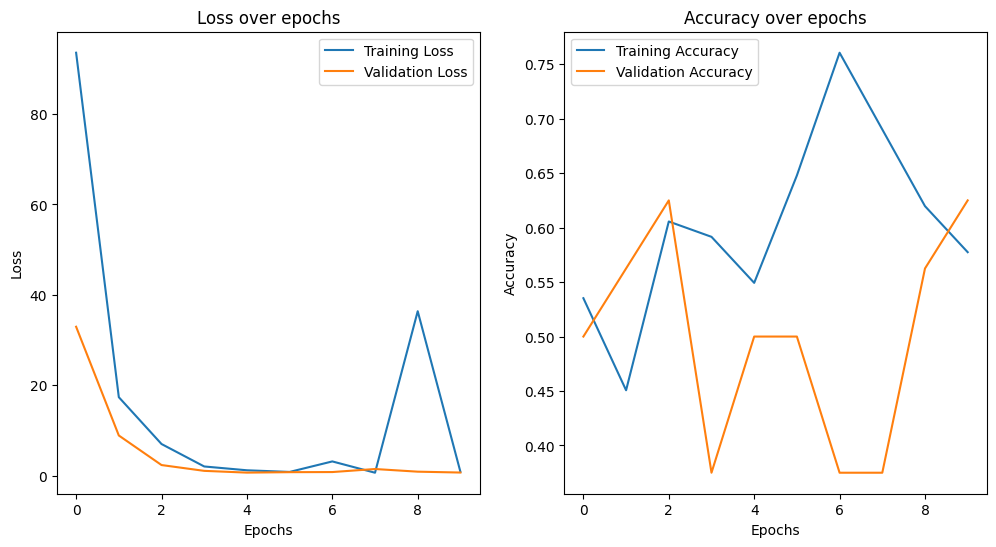

5/5 [==============================] - 4s 196ms/step
Weighted Precision: 0.22145328719723184
Weighted Recall: 0.47058823529411764
Weighted F1 Score: 0.30117647058823527
Micro Precision: 0.47058823529411764
Micro Recall: 0.47058823529411764
Micro F1 Score: 0.47058823529411764
Macro Precision: 0.23529411764705882
Macro Recall: 0.5
Macro F1 Score: 0.31999999999999995
Precision (None): [0.47058824 0.        ]
Recall (None): [1. 0.]
F1 Score (None): [0.64 0.  ]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [0.001, 0.01, 0.1]
epochs = 10  # Start with fewer epochs for testing

best_accuracy = 0
best_params = {}
all_results = []

base_models = {
    'MobileNetV2': MobileNetV2
}

results_file = 'training_resultsNASNetMobile.json'
if os.path.exists(results_file):
    with open(results_file, 'r') as file:
        all_results = json.load(file)
else:
    all_results = []

for model_name, base_model_fn in base_models.items():
    for activation in activations:
        for dropout_rate in dropout_rates:
            for learning_rate in learning_rates:
                try:
                    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
                    for layer in base_model.layers:
                        layer.trainable = False

                    x = GlobalAveragePooling2D()(base_model.output)
                    x = Dense(512, activation=activation)(x)
                    x = Dropout(dropout_rate)(x)
                    output = Dense(1, activation='sigmoid')(x)

                    model = Model(inputs=base_model.input, outputs=output)
                    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                                  loss='binary_crossentropy',
                                  metrics=['accuracy'])

                    history = model.fit(
                        train_generator,
                        steps_per_epoch=train_generator.samples // train_generator.batch_size,
                        epochs=epochs,
                        validation_data=val_generator,
                        validation_steps=val_generator.samples // val_generator.batch_size,
                        verbose=0
                    )

                    val_accuracy = history.history['val_accuracy'][-1]
                    result = {
                        'model': model_name,
                        'activation': activation,
                        'dropout_rate': dropout_rate,
                        'learning_rate': learning_rate,
                        'val_accuracy': val_accuracy,
                        'history': history.history
                    }
                    all_results.append(result)

                    if val_accuracy > best_accuracy:
                        best_accuracy = val_accuracy
                        best_params = result
                        best_output = output  # Kaydedilen çıktı tensoru

                    with open(results_file, 'w') as file:
                        json.dump(all_results, file)

                    print(f"Model: {model_name}, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}")

                except Exception as e:
                    print(f"Error with model {model_name}, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# En iyi modelin giriş ve çıkış tensorlarını kullanarak yeniden oluşturulması
base_model = NASNetMobile(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=best_params['activation'])(x)
x = Dropout(best_params['dropout_rate'])(x)
best_output = Dense(1, activation='sigmoid')(x)  # Kaydedilen çıktı tensoru kullanılmalı

best_model = Model(inputs=base_model.input, outputs=best_output)
best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
74836368/74836368 [==============================] - 4s 0us/step
Model: DenseNet201, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.001, Validation Accuracy: 0.3125
Model: DenseNet201, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.01, Validation Accuracy: 0.375
Model: DenseNet201, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.1, Validation Accuracy: 0.5
Model: DenseNet201, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.001, Validation Accuracy: 0.5625
Model: DenseNet201, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.01, Validation Accuracy: 0.375
Model: DenseNet201, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.1, Validation Accuracy: 0.5
Model: DenseNet201, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.001, Validation Accuracy: 0.1875
Model: DenseNet201, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.01, Validation Accuracy: 0.4375
Model: DenseNe

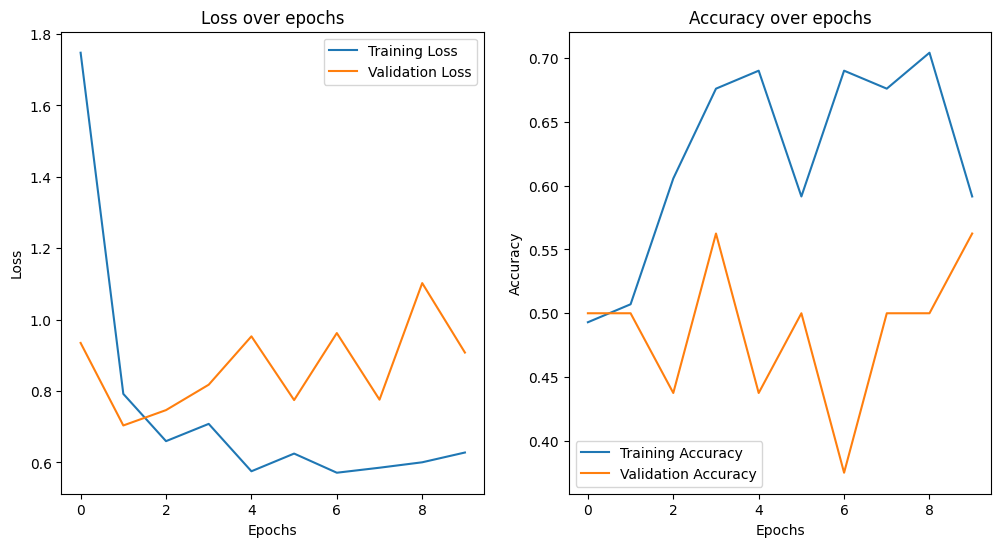

5/5 [==============================] - 4s 169ms/step
Weighted Precision: 0.40784313725490196
Weighted Recall: 0.4117647058823529
Weighted F1 Score: 0.38655462184873945
Micro Precision: 0.4117647058823529
Micro Recall: 0.4117647058823529
Micro F1 Score: 0.4117647058823529
Macro Precision: 0.4083333333333333
Macro Recall: 0.4236111111111111
Macro F1 Score: 0.39285714285714285
Precision (None): [0.41666667 0.4       ]
Recall (None): [0.625      0.22222222]
F1 Score (None): [0.5        0.28571429]


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [0.001, 0.01, 0.1]
epochs = 10  # Start with fewer epochs for testing

best_accuracy = 0
best_params = {}
all_results = []

base_models = {
    'DenseNet201': DenseNet201
}

results_file = 'training_resultsNASNetMobile.json'
if os.path.exists(results_file):
    with open(results_file, 'r') as file:
        all_results = json.load(file)
else:
    all_results = []

for model_name, base_model_fn in base_models.items():
    for activation in activations:
        for dropout_rate in dropout_rates:
            for learning_rate in learning_rates:
                try:
                    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
                    for layer in base_model.layers:
                        layer.trainable = False

                    x = GlobalAveragePooling2D()(base_model.output)
                    x = Dense(512, activation=activation)(x)
                    x = Dropout(dropout_rate)(x)
                    output = Dense(1, activation='sigmoid')(x)

                    model = Model(inputs=base_model.input, outputs=output)
                    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                                  loss='binary_crossentropy',
                                  metrics=['accuracy'])

                    history = model.fit(
                        train_generator,
                        steps_per_epoch=train_generator.samples // train_generator.batch_size,
                        epochs=epochs,
                        validation_data=val_generator,
                        validation_steps=val_generator.samples // val_generator.batch_size,
                        verbose=0
                    )

                    val_accuracy = history.history['val_accuracy'][-1]
                    result = {
                        'model': model_name,
                        'activation': activation,
                        'dropout_rate': dropout_rate,
                        'learning_rate': learning_rate,
                        'val_accuracy': val_accuracy,
                        'history': history.history
                    }
                    all_results.append(result)

                    if val_accuracy > best_accuracy:
                        best_accuracy = val_accuracy
                        best_params = result
                        best_output = output  # Kaydedilen çıktı tensoru

                    with open(results_file, 'w') as file:
                        json.dump(all_results, file)

                    print(f"Model: {model_name}, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}")

                except Exception as e:
                    print(f"Error with model {model_name}, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# En iyi modelin giriş ve çıkış tensorlarını kullanarak yeniden oluşturulması
base_model = NASNetMobile(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=best_params['activation'])(x)
x = Dropout(best_params['dropout_rate'])(x)
best_output = Dense(1, activation='sigmoid')(x)  # Kaydedilen çıktı tensoru kullanılmalı

best_model = Model(inputs=base_model.input, outputs=best_output)
best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
51877672/51877672 [==============================] - 3s 0us/step
Model: DenseNet169, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.001, Validation Accuracy: 0.4375
Model: DenseNet169, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.01, Validation Accuracy: 0.4375
Model: DenseNet169, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.1, Validation Accuracy: 0.5625
Model: DenseNet169, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.001, Validation Accuracy: 0.375
Model: DenseNet169, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.01, Validation Accuracy: 0.375
Model: DenseNet169, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.1, Validation Accuracy: 0.5
Model: DenseNet169, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.001, Validation Accuracy: 0.5
Model: DenseNet169, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.01, Validation Accuracy: 0.5625
Model: DenseNe

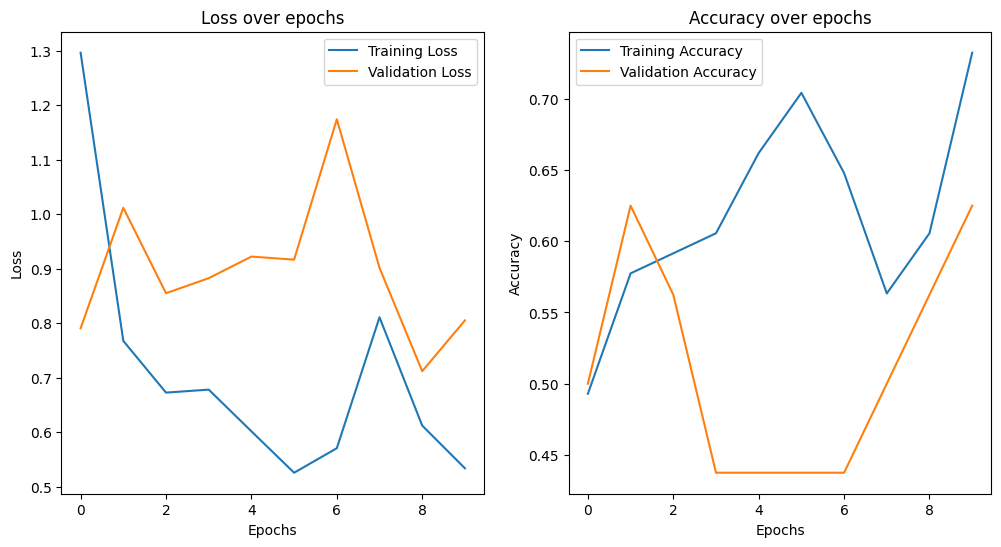

5/5 [==============================] - 4s 180ms/step
Weighted Precision: 0.31470588235294117
Weighted Recall: 0.35294117647058826
Weighted F1 Score: 0.32449903038138334
Micro Precision: 0.35294117647058826
Micro Recall: 0.35294117647058826
Micro F1 Score: 0.35294117647058826
Macro Precision: 0.30833333333333335
Macro Recall: 0.3402777777777778
Macro F1 Score: 0.315018315018315
Precision (None): [0.2        0.41666667]
Recall (None): [0.125      0.55555556]
F1 Score (None): [0.15384615 0.47619048]


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [0.001, 0.01, 0.1]
epochs = 10  # Start with fewer epochs for testing

best_accuracy = 0
best_params = {}
all_results = []

base_models = {
    'DenseNet169': DenseNet169
}

results_file = 'training_resultsNASNetMobile.json'
if os.path.exists(results_file):
    with open(results_file, 'r') as file:
        all_results = json.load(file)
else:
    all_results = []

for model_name, base_model_fn in base_models.items():
    for activation in activations:
        for dropout_rate in dropout_rates:
            for learning_rate in learning_rates:
                try:
                    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
                    for layer in base_model.layers:
                        layer.trainable = False

                    x = GlobalAveragePooling2D()(base_model.output)
                    x = Dense(512, activation=activation)(x)
                    x = Dropout(dropout_rate)(x)
                    output = Dense(1, activation='sigmoid')(x)

                    model = Model(inputs=base_model.input, outputs=output)
                    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                                  loss='binary_crossentropy',
                                  metrics=['accuracy'])

                    history = model.fit(
                        train_generator,
                        steps_per_epoch=train_generator.samples // train_generator.batch_size,
                        epochs=epochs,
                        validation_data=val_generator,
                        validation_steps=val_generator.samples // val_generator.batch_size,
                        verbose=0
                    )

                    val_accuracy = history.history['val_accuracy'][-1]
                    result = {
                        'model': model_name,
                        'activation': activation,
                        'dropout_rate': dropout_rate,
                        'learning_rate': learning_rate,
                        'val_accuracy': val_accuracy,
                        'history': history.history
                    }
                    all_results.append(result)

                    if val_accuracy > best_accuracy:
                        best_accuracy = val_accuracy
                        best_params = result
                        best_output = output  # Kaydedilen çıktı tensoru

                    with open(results_file, 'w') as file:
                        json.dump(all_results, file)

                    print(f"Model: {model_name}, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}")

                except Exception as e:
                    print(f"Error with model {model_name}, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# En iyi modelin giriş ve çıkış tensorlarını kullanarak yeniden oluşturulması
base_model = NASNetMobile(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=best_params['activation'])(x)
x = Dropout(best_params['dropout_rate'])(x)
best_output = Dense(1, activation='sigmoid')(x)  # Kaydedilen çıktı tensoru kullanılmalı

best_model = Model(inputs=base_model.input, outputs=best_output)
best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
29084464/29084464 [==============================] - 2s 0us/step
Model: DenseNet121, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.001, Validation Accuracy: 0.5
Model: DenseNet121, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.01, Validation Accuracy: 0.5
Model: DenseNet121, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.1, Validation Accuracy: 0.5
Model: DenseNet121, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.001, Validation Accuracy: 0.4375
Model: DenseNet121, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.01, Validation Accuracy: 0.5
Model: DenseNet121, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.1, Validation Accuracy: 0.4375
Model: DenseNet121, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.001, Validation Accuracy: 0.5
Model: DenseNet121, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.01, Validation Accuracy: 0.5625
Model: DenseNet121, A

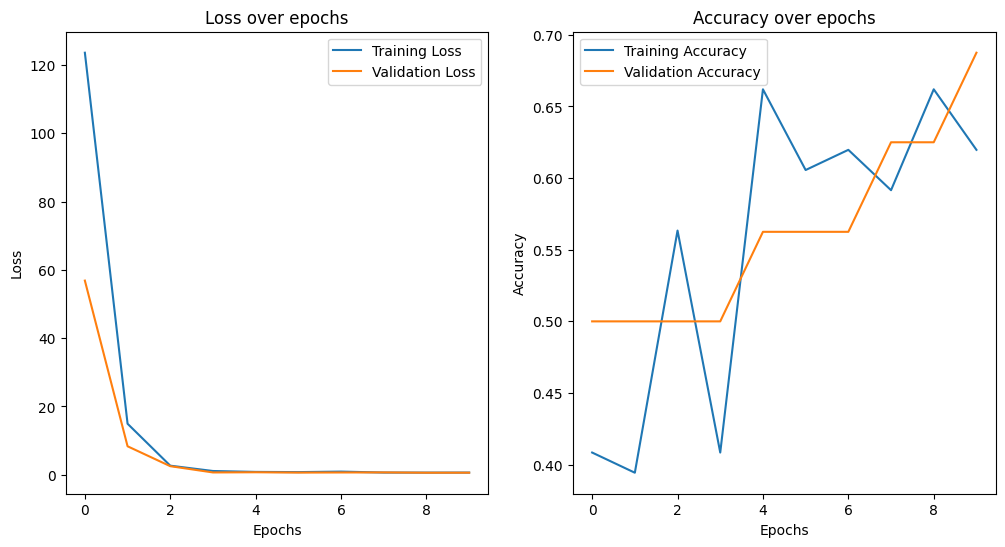

5/5 [==============================] - 5s 173ms/step
Weighted Precision: 0.7647058823529411
Weighted Recall: 0.5294117647058824
Weighted F1 Score: 0.41960784313725485
Micro Precision: 0.5294117647058824
Micro Recall: 0.5294117647058824
Micro F1 Score: 0.5294117647058824
Macro Precision: 0.75
Macro Recall: 0.5555555555555556
Macro F1 Score: 0.4333333333333333
Precision (None): [0.5 1. ]
Recall (None): [1.         0.11111111]
F1 Score (None): [0.66666667 0.2       ]


In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [0.001, 0.01, 0.1]
epochs = 10  # Start with fewer epochs for testing

best_accuracy = 0
best_params = {}
all_results = []

base_models = {
     'DenseNet121': DenseNet121
}

results_file = 'training_resultsNASNetMobile.json'
if os.path.exists(results_file):
    with open(results_file, 'r') as file:
        all_results = json.load(file)
else:
    all_results = []

for model_name, base_model_fn in base_models.items():
    for activation in activations:
        for dropout_rate in dropout_rates:
            for learning_rate in learning_rates:
                try:
                    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
                    for layer in base_model.layers:
                        layer.trainable = False

                    x = GlobalAveragePooling2D()(base_model.output)
                    x = Dense(512, activation=activation)(x)
                    x = Dropout(dropout_rate)(x)
                    output = Dense(1, activation='sigmoid')(x)

                    model = Model(inputs=base_model.input, outputs=output)
                    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                                  loss='binary_crossentropy',
                                  metrics=['accuracy'])

                    history = model.fit(
                        train_generator,
                        steps_per_epoch=train_generator.samples // train_generator.batch_size,
                        epochs=epochs,
                        validation_data=val_generator,
                        validation_steps=val_generator.samples // val_generator.batch_size,
                        verbose=0
                    )

                    val_accuracy = history.history['val_accuracy'][-1]
                    result = {
                        'model': model_name,
                        'activation': activation,
                        'dropout_rate': dropout_rate,
                        'learning_rate': learning_rate,
                        'val_accuracy': val_accuracy,
                        'history': history.history
                    }
                    all_results.append(result)

                    if val_accuracy > best_accuracy:
                        best_accuracy = val_accuracy
                        best_params = result
                        best_output = output  # Kaydedilen çıktı tensoru

                    with open(results_file, 'w') as file:
                        json.dump(all_results, file)

                    print(f"Model: {model_name}, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}")

                except Exception as e:
                    print(f"Error with model {model_name}, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# En iyi modelin giriş ve çıkış tensorlarını kullanarak yeniden oluşturulması
base_model = NASNetMobile(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=best_params['activation'])(x)
x = Dropout(best_params['dropout_rate'])(x)
best_output = Dense(1, activation='sigmoid')(x)  # Kaydedilen çıktı tensoru kullanılmalı

best_model = Model(inputs=base_model.input, outputs=best_output)
best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
87910968/87910968 [==============================] - 5s 0us/step
Model: InceptionV3, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.001, Validation Accuracy: 0.4375
Model: InceptionV3, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.01, Validation Accuracy: 0.375
Model: InceptionV3, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.1, Validation Accuracy: 0.4375
Model: InceptionV3, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.001, Validation Accuracy: 0.5
Model: InceptionV3, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.01, Validation Accuracy: 0.5625
Model: InceptionV3, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.1, Validation Accuracy: 0.4375
Model: InceptionV3, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.001, Validation Accuracy: 0.375
Model: InceptionV3, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.01, Validation Accuracy: 0.375
Model: Incep

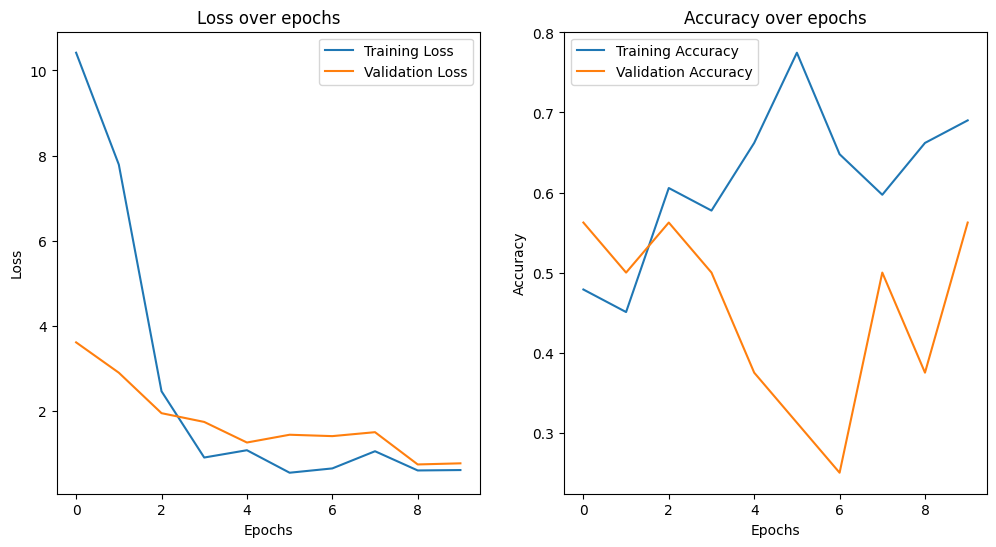

5/5 [==============================] - 4s 171ms/step
Weighted Precision: 0.5378151260504201
Weighted Recall: 0.5294117647058824
Weighted F1 Score: 0.5261437908496732
Micro Precision: 0.5294117647058824
Micro Recall: 0.5294117647058824
Micro F1 Score: 0.5294117647058824
Macro Precision: 0.5357142857142857
Macro Recall: 0.5347222222222222
Macro F1 Score: 0.5277777777777778
Precision (None): [0.5        0.57142857]
Recall (None): [0.625      0.44444444]
F1 Score (None): [0.55555556 0.5       ]


In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [0.001, 0.01, 0.1]
epochs = 10  # Start with fewer epochs for testing

best_accuracy = 0
best_params = {}
all_results = []

base_models = {
      'InceptionV3': InceptionV3
}

results_file = 'training_resultsNASNetMobile.json'
if os.path.exists(results_file):
    with open(results_file, 'r') as file:
        all_results = json.load(file)
else:
    all_results = []

for model_name, base_model_fn in base_models.items():
    for activation in activations:
        for dropout_rate in dropout_rates:
            for learning_rate in learning_rates:
                try:
                    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
                    for layer in base_model.layers:
                        layer.trainable = False

                    x = GlobalAveragePooling2D()(base_model.output)
                    x = Dense(512, activation=activation)(x)
                    x = Dropout(dropout_rate)(x)
                    output = Dense(1, activation='sigmoid')(x)

                    model = Model(inputs=base_model.input, outputs=output)
                    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                                  loss='binary_crossentropy',
                                  metrics=['accuracy'])

                    history = model.fit(
                        train_generator,
                        steps_per_epoch=train_generator.samples // train_generator.batch_size,
                        epochs=epochs,
                        validation_data=val_generator,
                        validation_steps=val_generator.samples // val_generator.batch_size,
                        verbose=0
                    )

                    val_accuracy = history.history['val_accuracy'][-1]
                    result = {
                        'model': model_name,
                        'activation': activation,
                        'dropout_rate': dropout_rate,
                        'learning_rate': learning_rate,
                        'val_accuracy': val_accuracy,
                        'history': history.history
                    }
                    all_results.append(result)

                    if val_accuracy > best_accuracy:
                        best_accuracy = val_accuracy
                        best_params = result
                        best_output = output  # Kaydedilen çıktı tensoru

                    with open(results_file, 'w') as file:
                        json.dump(all_results, file)

                    print(f"Model: {model_name}, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}")

                except Exception as e:
                    print(f"Error with model {model_name}, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# En iyi modelin giriş ve çıkış tensorlarını kullanarak yeniden oluşturulması
base_model = NASNetMobile(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=best_params['activation'])(x)
x = Dropout(best_params['dropout_rate'])(x)
best_output = Dense(1, activation='sigmoid')(x)  # Kaydedilen çıktı tensoru kullanılmalı

best_model = Model(inputs=base_model.input, outputs=best_output)
best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
80134624/80134624 [==============================] - 4s 0us/step
Model: VGG19, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.001, Validation Accuracy: 0.3125
Model: VGG19, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.01, Validation Accuracy: 0.5
Model: VGG19, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.1, Validation Accuracy: 0.5
Model: VGG19, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.001, Validation Accuracy: 0.5625
Model: VGG19, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.01, Validation Accuracy: 0.5625
Model: VGG19, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.1, Validation Accuracy: 0.5625
Model: VGG19, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.001, Validation Accuracy: 0.5
Model: VGG19, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.01, Validation Accuracy: 0.5
Model: VGG19, Activation: relu, Dropout Rate: 0.2, Learning Rate: 

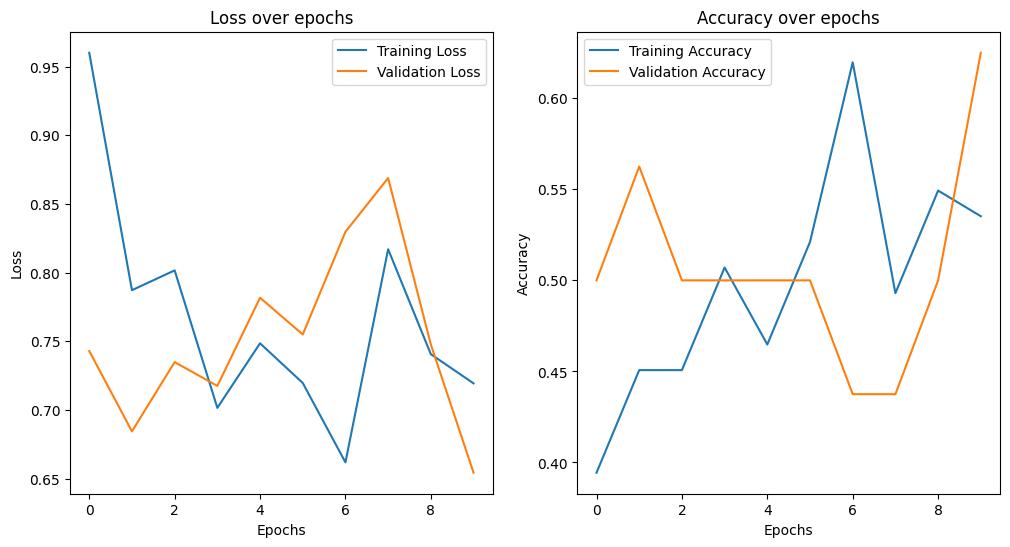

5/5 [==============================] - 4s 172ms/step
Weighted Precision: 0.22145328719723184
Weighted Recall: 0.47058823529411764
Weighted F1 Score: 0.30117647058823527
Micro Precision: 0.47058823529411764
Micro Recall: 0.47058823529411764
Micro F1 Score: 0.47058823529411764
Macro Precision: 0.23529411764705882
Macro Recall: 0.5
Macro F1 Score: 0.31999999999999995
Precision (None): [0.47058824 0.        ]
Recall (None): [1. 0.]
F1 Score (None): [0.64 0.  ]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [0.001, 0.01, 0.1]
epochs = 10  # Start with fewer epochs for testing

best_accuracy = 0
best_params = {}
all_results = []

base_models = {
      'VGG19': VGG19
}

results_file = 'training_resultsNASNetMobile.json'
if os.path.exists(results_file):
    with open(results_file, 'r') as file:
        all_results = json.load(file)
else:
    all_results = []

for model_name, base_model_fn in base_models.items():
    for activation in activations:
        for dropout_rate in dropout_rates:
            for learning_rate in learning_rates:
                try:
                    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
                    for layer in base_model.layers:
                        layer.trainable = False

                    x = GlobalAveragePooling2D()(base_model.output)
                    x = Dense(512, activation=activation)(x)
                    x = Dropout(dropout_rate)(x)
                    output = Dense(1, activation='sigmoid')(x)

                    model = Model(inputs=base_model.input, outputs=output)
                    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                                  loss='binary_crossentropy',
                                  metrics=['accuracy'])

                    history = model.fit(
                        train_generator,
                        steps_per_epoch=train_generator.samples // train_generator.batch_size,
                        epochs=epochs,
                        validation_data=val_generator,
                        validation_steps=val_generator.samples // val_generator.batch_size,
                        verbose=0
                    )

                    val_accuracy = history.history['val_accuracy'][-1]
                    result = {
                        'model': model_name,
                        'activation': activation,
                        'dropout_rate': dropout_rate,
                        'learning_rate': learning_rate,
                        'val_accuracy': val_accuracy,
                        'history': history.history
                    }
                    all_results.append(result)

                    if val_accuracy > best_accuracy:
                        best_accuracy = val_accuracy
                        best_params = result
                        best_output = output  # Kaydedilen çıktı tensoru

                    with open(results_file, 'w') as file:
                        json.dump(all_results, file)

                    print(f"Model: {model_name}, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}")

                except Exception as e:
                    print(f"Error with model {model_name}, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# En iyi modelin giriş ve çıkış tensorlarını kullanarak yeniden oluşturulması
base_model = NASNetMobile(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=best_params['activation'])(x)
x = Dropout(best_params['dropout_rate'])(x)
best_output = Dense(1, activation='sigmoid')(x)  # Kaydedilen çıktı tensoru kullanılmalı

best_model = Model(inputs=base_model.input, outputs=best_output)
best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
58889256/58889256 [==============================] - 0s 0us/step
Model: VGG16, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.001, Validation Accuracy: 0.4375
Model: VGG16, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.01, Validation Accuracy: 0.5625
Model: VGG16, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.1, Validation Accuracy: 0.5
Model: VGG16, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.001, Validation Accuracy: 0.4375
Model: VGG16, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.01, Validation Accuracy: 0.5
Model: VGG16, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.1, Validation Accuracy: 0.5
Model: VGG16, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.001, Validation Accuracy: 0.5625
Model: VGG16, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.01, Validation Accuracy: 0.5625
Model: VGG16, Activation: relu, Dropout Rate: 0.2, Learning Rat

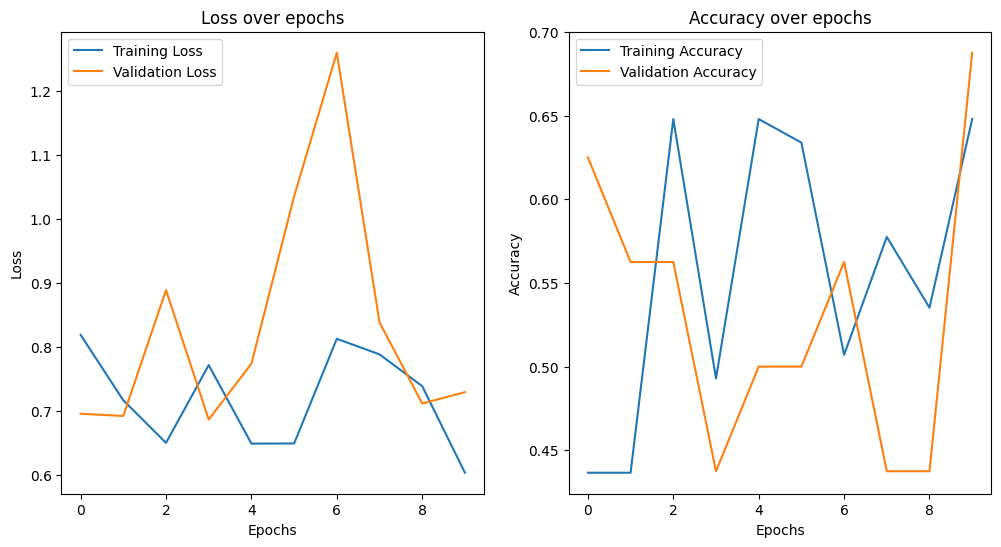

5/5 [==============================] - 5s 186ms/step
Weighted Precision: 0.5294117647058824
Weighted Recall: 0.5294117647058824
Weighted F1 Score: 0.5294117647058824
Micro Precision: 0.5294117647058824
Micro Recall: 0.5294117647058824
Micro F1 Score: 0.5294117647058824
Macro Precision: 0.5277777777777778
Macro Recall: 0.5277777777777778
Macro F1 Score: 0.5277777777777778
Precision (None): [0.5        0.55555556]
Recall (None): [0.5        0.55555556]
F1 Score (None): [0.5        0.55555556]


In [4]:

from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import (
    ResNet50, EfficientNetB0, VGG16, VGG19, InceptionV3,
    DenseNet121, DenseNet169, DenseNet201, MobileNetV2, NASNetMobile
)
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [0.001, 0.01, 0.1]
epochs = 10  # Start with fewer epochs for testing

best_accuracy = 0
best_params = {}
all_results = []

base_models = {
    'VGG16': VGG16
}

results_file = 'training_resultsNASNetMobile.json'
if os.path.exists(results_file):
    with open(results_file, 'r') as file:
        all_results = json.load(file)
else:
    all_results = []

for model_name, base_model_fn in base_models.items():
    for activation in activations:
        for dropout_rate in dropout_rates:
            for learning_rate in learning_rates:
                try:
                    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
                    for layer in base_model.layers:
                        layer.trainable = False

                    x = GlobalAveragePooling2D()(base_model.output)
                    x = Dense(512, activation=activation)(x)
                    x = Dropout(dropout_rate)(x)
                    output = Dense(1, activation='sigmoid')(x)

                    model = Model(inputs=base_model.input, outputs=output)
                    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                                  loss='binary_crossentropy',
                                  metrics=['accuracy'])

                    history = model.fit(
                        train_generator,
                        steps_per_epoch=train_generator.samples // train_generator.batch_size,
                        epochs=epochs,
                        validation_data=val_generator,
                        validation_steps=val_generator.samples // val_generator.batch_size,
                        verbose=0
                    )

                    val_accuracy = history.history['val_accuracy'][-1]
                    result = {
                        'model': model_name,
                        'activation': activation,
                        'dropout_rate': dropout_rate,
                        'learning_rate': learning_rate,
                        'val_accuracy': val_accuracy,
                        'history': history.history
                    }
                    all_results.append(result)

                    if val_accuracy > best_accuracy:
                        best_accuracy = val_accuracy
                        best_params = result
                        best_output = output  # Kaydedilen çıktı tensoru

                    with open(results_file, 'w') as file:
                        json.dump(all_results, file)

                    print(f"Model: {model_name}, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}")

                except Exception as e:
                    print(f"Error with model {model_name}, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# En iyi modelin giriş ve çıkış tensorlarını kullanarak yeniden oluşturulması
base_model = NASNetMobile(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=best_params['activation'])(x)
x = Dropout(best_params['dropout_rate'])(x)
best_output = Dense(1, activation='sigmoid')(x)  # Kaydedilen çıktı tensoru kullanılmalı

best_model = Model(inputs=base_model.input, outputs=best_output)
best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
16705208/16705208 [==============================] - 0s 0us/step
Model: EfficientNetB0, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.001, Validation Accuracy: 0.5625
Model: EfficientNetB0, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.01, Validation Accuracy: 0.5625
Model: EfficientNetB0, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.1, Validation Accuracy: 0.5625
Model: EfficientNetB0, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.001, Validation Accuracy: 0.5625
Model: EfficientNetB0, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.01, Validation Accuracy: 0.5
Model: EfficientNetB0, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.1, Validation Accuracy: 0.5
Model: EfficientNetB0, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.001, Validation Accuracy: 0.5
Model: EfficientNetB0, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.01, Validation Accuracy

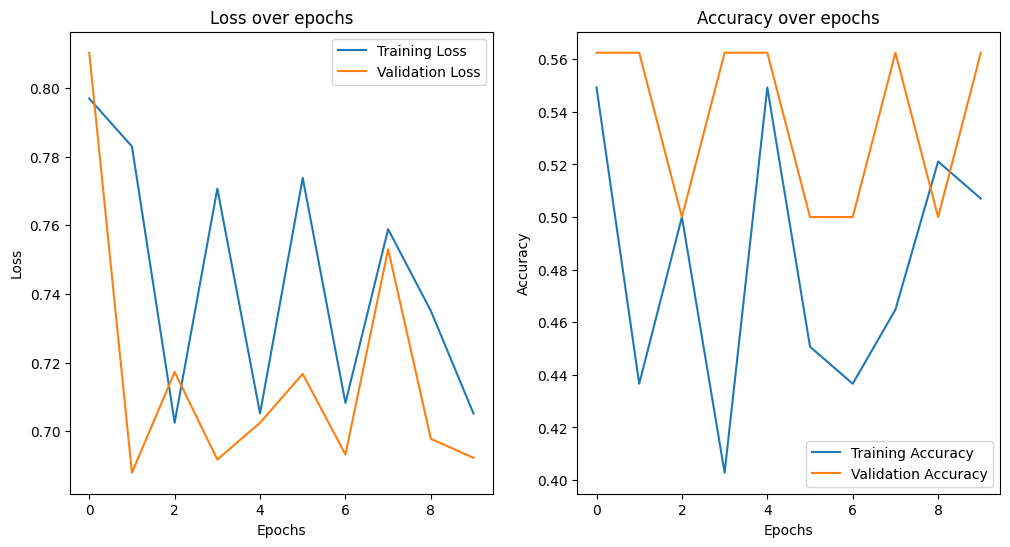

5/5 [==============================] - 5s 186ms/step
Weighted Precision: 0.22145328719723184
Weighted Recall: 0.47058823529411764
Weighted F1 Score: 0.30117647058823527
Micro Precision: 0.47058823529411764
Micro Recall: 0.47058823529411764
Micro F1 Score: 0.47058823529411764
Macro Precision: 0.23529411764705882
Macro Recall: 0.5
Macro F1 Score: 0.31999999999999995
Precision (None): [0.47058824 0.        ]
Recall (None): [1. 0.]
F1 Score (None): [0.64 0.  ]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [5]:

from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import (
    ResNet50, EfficientNetB0, VGG16, VGG19, InceptionV3,
    DenseNet121, DenseNet169, DenseNet201, MobileNetV2, NASNetMobile
)
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [0.001, 0.01, 0.1]
epochs = 10  # Start with fewer epochs for testing

best_accuracy = 0
best_params = {}
all_results = []

base_models = {
    'EfficientNetB0': EfficientNetB0
}

results_file = 'training_resultsNASNetMobile.json'
if os.path.exists(results_file):
    with open(results_file, 'r') as file:
        all_results = json.load(file)
else:
    all_results = []

for model_name, base_model_fn in base_models.items():
    for activation in activations:
        for dropout_rate in dropout_rates:
            for learning_rate in learning_rates:
                try:
                    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
                    for layer in base_model.layers:
                        layer.trainable = False

                    x = GlobalAveragePooling2D()(base_model.output)
                    x = Dense(512, activation=activation)(x)
                    x = Dropout(dropout_rate)(x)
                    output = Dense(1, activation='sigmoid')(x)

                    model = Model(inputs=base_model.input, outputs=output)
                    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                                  loss='binary_crossentropy',
                                  metrics=['accuracy'])

                    history = model.fit(
                        train_generator,
                        steps_per_epoch=train_generator.samples // train_generator.batch_size,
                        epochs=epochs,
                        validation_data=val_generator,
                        validation_steps=val_generator.samples // val_generator.batch_size,
                        verbose=0
                    )

                    val_accuracy = history.history['val_accuracy'][-1]
                    result = {
                        'model': model_name,
                        'activation': activation,
                        'dropout_rate': dropout_rate,
                        'learning_rate': learning_rate,
                        'val_accuracy': val_accuracy,
                        'history': history.history
                    }
                    all_results.append(result)

                    if val_accuracy > best_accuracy:
                        best_accuracy = val_accuracy
                        best_params = result
                        best_output = output  # Kaydedilen çıktı tensoru

                    with open(results_file, 'w') as file:
                        json.dump(all_results, file)

                    print(f"Model: {model_name}, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}")

                except Exception as e:
                    print(f"Error with model {model_name}, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# En iyi modelin giriş ve çıkış tensorlarını kullanarak yeniden oluşturulması
base_model = NASNetMobile(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=best_params['activation'])(x)
x = Dropout(best_params['dropout_rate'])(x)
best_output = Dense(1, activation='sigmoid')(x)  # Kaydedilen çıktı tensoru kullanılmalı

best_model = Model(inputs=base_model.input, outputs=best_output)
best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)


   'ResNet50': ResNet50,
    'EfficientNetB0': EfficientNetB0,
,
    ::
    


Found 75 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
94765736/94765736 [==============================] - 0s 0us/step
Model: ResNet50, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.001, Validation Accuracy: 0.5
Model: ResNet50, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.01, Validation Accuracy: 0.5
Model: ResNet50, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.1, Validation Accuracy: 0.5
Model: ResNet50, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.001, Validation Accuracy: 0.5
Model: ResNet50, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.01, Validation Accuracy: 0.5
Model: ResNet50, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.1, Validation Accuracy: 0.5625
Model: ResNet50, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.001, Validation Accuracy: 0.5625
Model: ResNet50, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.01, Validation Accuracy: 0.5
Model: ResNet50, Activation: relu, Dropout Rate:

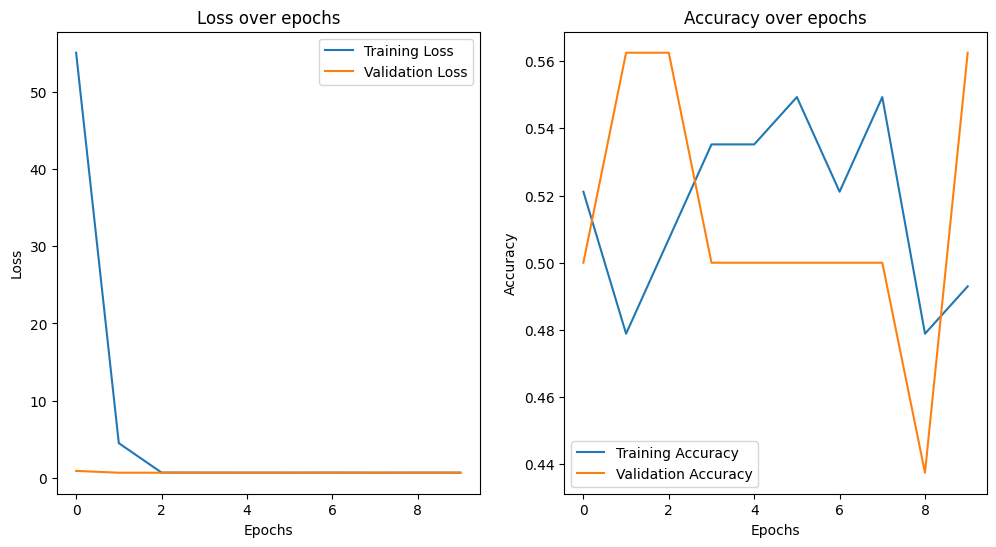

5/5 [==============================] - 6s 187ms/step
Weighted Precision: 0.41512605042016804
Weighted Recall: 0.4117647058823529
Weighted F1 Score: 0.4076797385620915
Micro Precision: 0.4117647058823529
Micro Recall: 0.4117647058823529
Micro F1 Score: 0.4117647058823529
Macro Precision: 0.41428571428571426
Macro Recall: 0.41666666666666663
Macro F1 Score: 0.4097222222222222
Precision (None): [0.4        0.42857143]
Recall (None): [0.5        0.33333333]
F1 Score (None): [0.44444444 0.375     ]


In [6]:

from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import (
    ResNet50, EfficientNetB0, VGG16, VGG19, InceptionV3,
    DenseNet121, DenseNet169, DenseNet201, MobileNetV2, NASNetMobile
)
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/Bitirme Çalışması/zararlı-zararsızGraf'
img_height = 224
img_width = 224
batch_size = 4

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['cleaned_codes_Graf', 'z-cleaned_codes_Graf']
)

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [0.001, 0.01, 0.1]
epochs = 10  # Start with fewer epochs for testing

best_accuracy = 0
best_params = {}
all_results = []

base_models = {
    'ResNet50': ResNet50
}

results_file = 'training_resultsNASNetMobile.json'
if os.path.exists(results_file):
    with open(results_file, 'r') as file:
        all_results = json.load(file)
else:
    all_results = []

for model_name, base_model_fn in base_models.items():
    for activation in activations:
        for dropout_rate in dropout_rates:
            for learning_rate in learning_rates:
                try:
                    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
                    for layer in base_model.layers:
                        layer.trainable = False

                    x = GlobalAveragePooling2D()(base_model.output)
                    x = Dense(512, activation=activation)(x)
                    x = Dropout(dropout_rate)(x)
                    output = Dense(1, activation='sigmoid')(x)

                    model = Model(inputs=base_model.input, outputs=output)
                    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                                  loss='binary_crossentropy',
                                  metrics=['accuracy'])

                    history = model.fit(
                        train_generator,
                        steps_per_epoch=train_generator.samples // train_generator.batch_size,
                        epochs=epochs,
                        validation_data=val_generator,
                        validation_steps=val_generator.samples // val_generator.batch_size,
                        verbose=0
                    )

                    val_accuracy = history.history['val_accuracy'][-1]
                    result = {
                        'model': model_name,
                        'activation': activation,
                        'dropout_rate': dropout_rate,
                        'learning_rate': learning_rate,
                        'val_accuracy': val_accuracy,
                        'history': history.history
                    }
                    all_results.append(result)

                    if val_accuracy > best_accuracy:
                        best_accuracy = val_accuracy
                        best_params = result
                        best_output = output  # Kaydedilen çıktı tensoru

                    with open(results_file, 'w') as file:
                        json.dump(all_results, file)

                    print(f"Model: {model_name}, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}")

                except Exception as e:
                    print(f"Error with model {model_name}, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# En iyi modelin giriş ve çıkış tensorlarını kullanarak yeniden oluşturulması
base_model = NASNetMobile(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation=best_params['activation'])(x)
x = Dropout(best_params['dropout_rate'])(x)
best_output = Dense(1, activation='sigmoid')(x)  # Kaydedilen çıktı tensoru kullanılmalı

best_model = Model(inputs=base_model.input, outputs=best_output)
best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)
